In [1]:
from statistics import linear_regression

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import alpha

In [2]:
df = pd.read_csv('Ecommerce Customers')

In [3]:
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    str    
 1   Address               500 non-null    str    
 2   Avatar                500 non-null    str    
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), str(3)
memory usage: 31.4 KB


In [5]:
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [6]:
df.duplicated().sum()

np.int64(0)

EDA

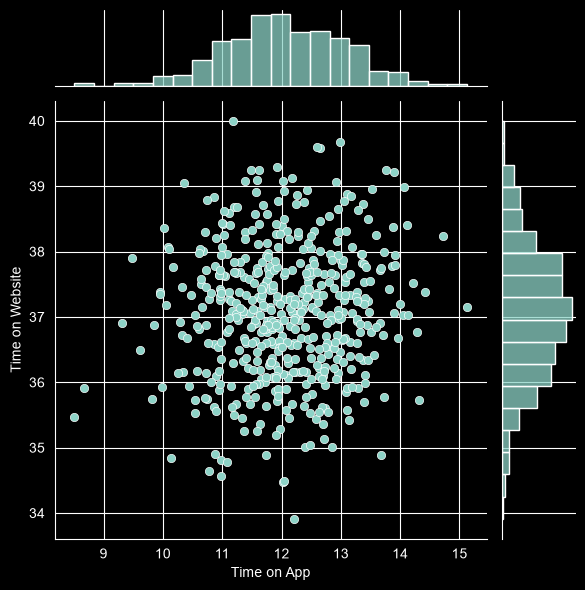

In [7]:
sns.jointplot(x = 'Time on App' , y = 'Time on Website' , data = df)

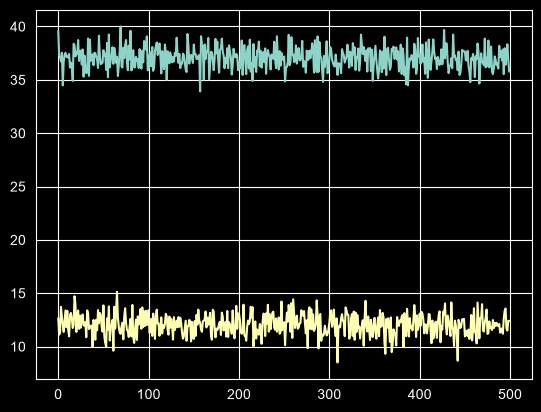

In [8]:
plt.plot(df['Time on Website'])
plt.plot(df['Time on App'])


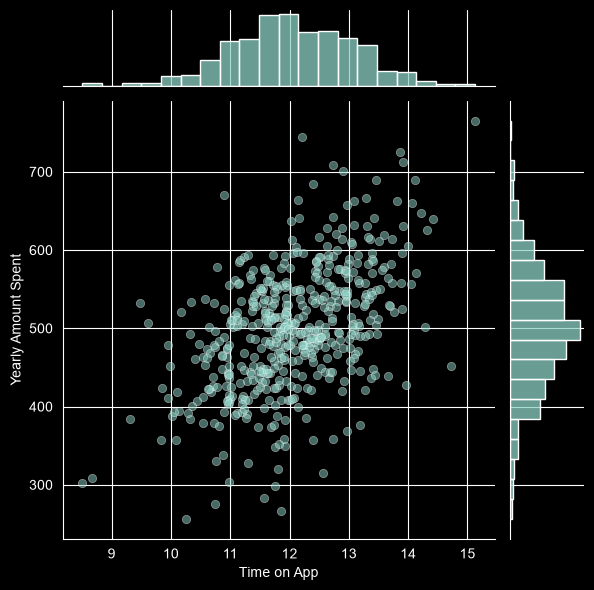

In [9]:
sns.jointplot(x='Time on App', y='Yearly Amount Spent', data=df , alpha = 0.5)

In [10]:
df.columns

Index(['Email', 'Address', 'Avatar', 'Avg. Session Length', 'Time on App',
       'Time on Website', 'Length of Membership', 'Yearly Amount Spent'],
      dtype='str')

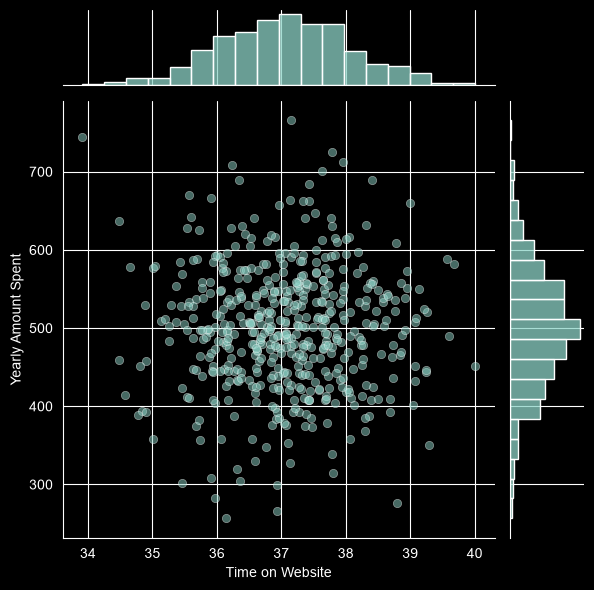

In [11]:
sns.jointplot(x='Time on Website', y='Yearly Amount Spent', data=df , alpha = 0.5)

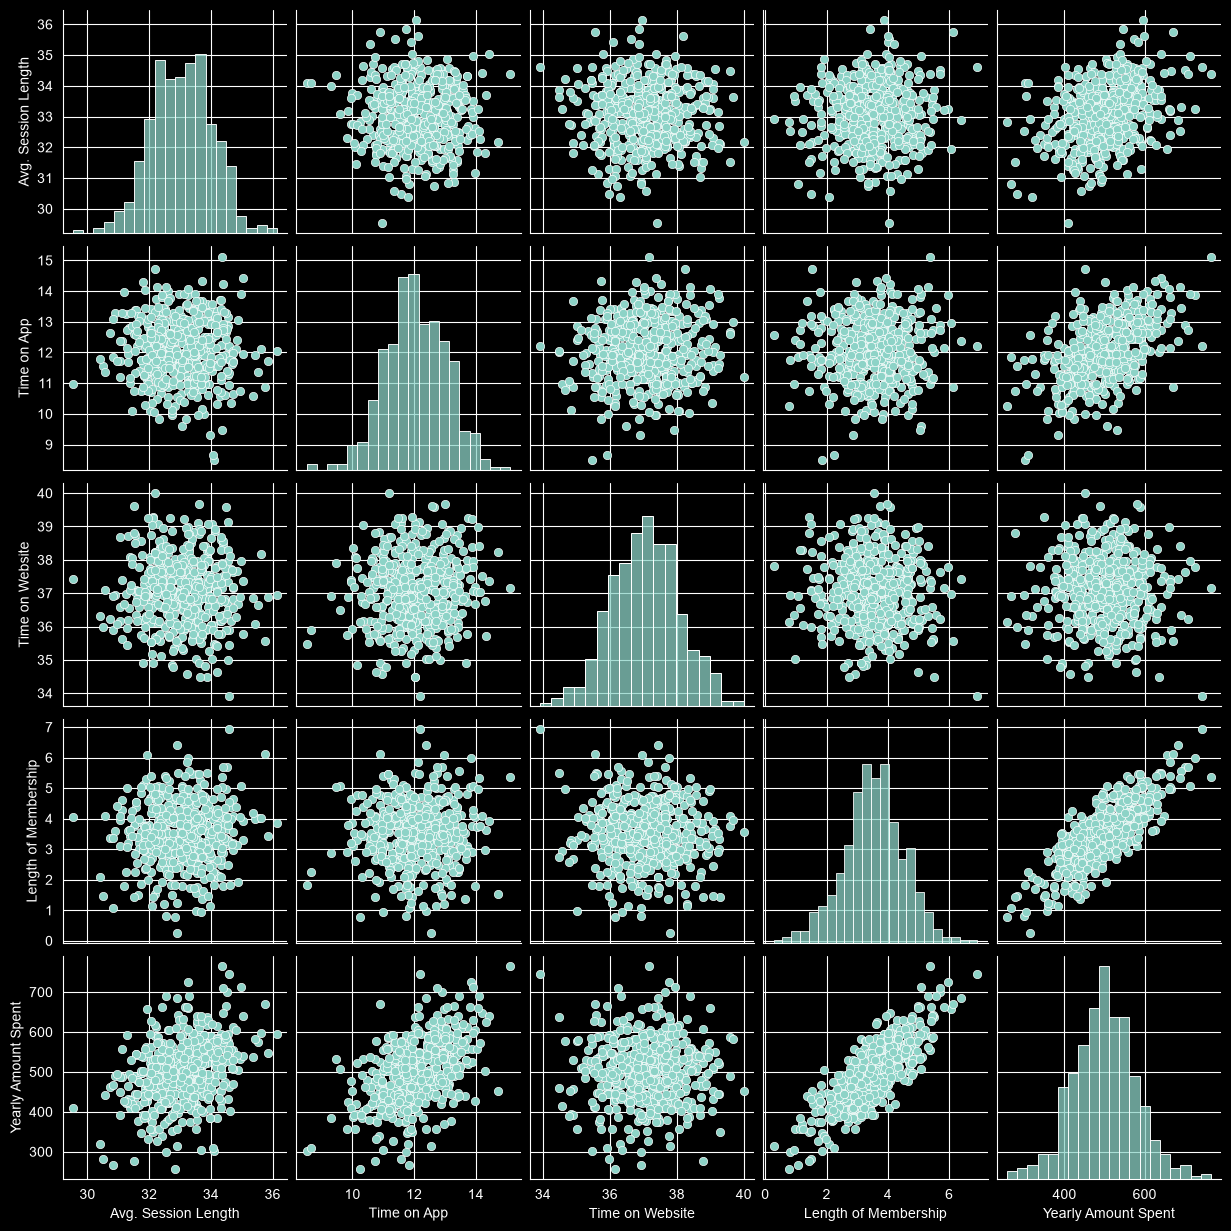

In [12]:
sns.pairplot(df, kind='scatter' )

<Axes: >

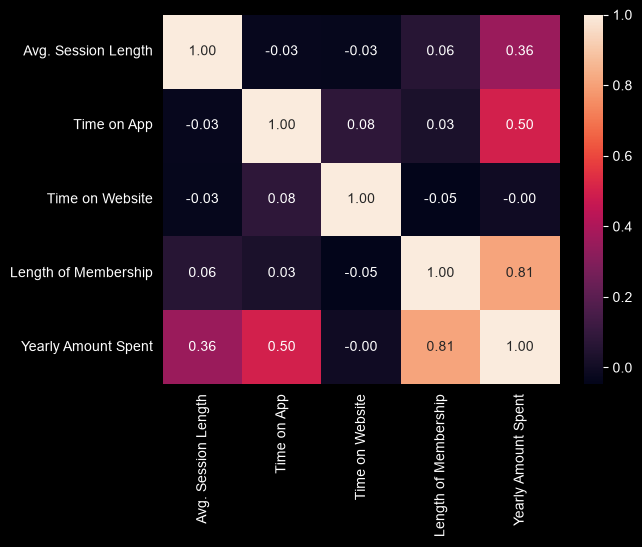

In [13]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr , annot = True, fmt = '.2f' )

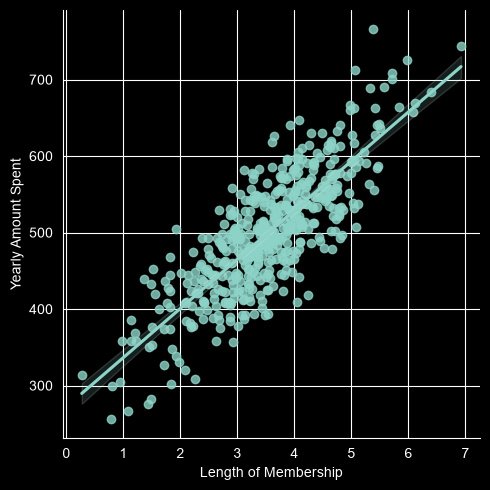

In [14]:
sns.lmplot(x = 'Length of Membership'  , y = 'Yearly Amount Spent' , data = df   )

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error , r2_score

In [16]:
x = df[['Avg. Session Length', 'Time on App',
       'Time on Website', 'Length of Membership']]   ### features
y = df['Yearly Amount Spent'] ## actual values

In [27]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size = 0.3 , random_state = 42)

In [28]:
model = LinearRegression()     ### model creation

In [29]:
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[25.72,38.6 , 0.46,61.67]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Avg. Session Length','Time on App','Time on Website', 'Length of Membership']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1051
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [30]:
print(f"weight {model.coef_}")
print(f" Bias   {model.intercept_}")

weight [25.72425621 38.59713548  0.45914788 61.67473243]
 Bias   -1050.6536746645725


In [31]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(350, 4)
(150, 4)
(350,)
(150,)


In [37]:
y_predict = model.predict(x_test)

In [38]:
mean_squared_error(y_test,y_predict)

103.91554136503333

In [41]:
r2_score(y_test, y_predict)

0.9808757641125855

In [43]:
y_predict

(array([403.66993069, 542.57756289, 427.06591658, 502.02460425,
        410.12143559, 569.93442508, 531.93431341, 506.29650969,
        408.71870658, 473.97737105, 441.46912726, 425.33703059,
        425.1297229 , 527.61676714, 431.45684016, 424.0769184 ,
        575.76543296, 484.89856554, 458.35936863, 481.96502182,
        502.32441491, 513.63783554, 507.58877002, 646.57464283,
        450.24372141, 496.27043415, 556.40457807, 554.95630839,
        399.64237199, 325.84623136, 532.89783259, 478.12238702,
        501.05701845, 305.97335848, 505.77244448, 483.79591969,
        518.8331528 , 438.18241857, 456.71094234, 471.04609461,
        494.44008972, 445.31155755, 508.78802753, 501.04594193,
        488.83499673, 535.38079541, 595.20129802, 514.04714872,
        280.76758312, 433.10112367, 421.70823427, 481.23640152,
        584.71372272, 608.7748096 , 563.98513427, 494.72804869,
        394.52133407, 456.4197529 , 573.08767515, 499.6984241 ,
        512.83277025, 392.12434043, 480.

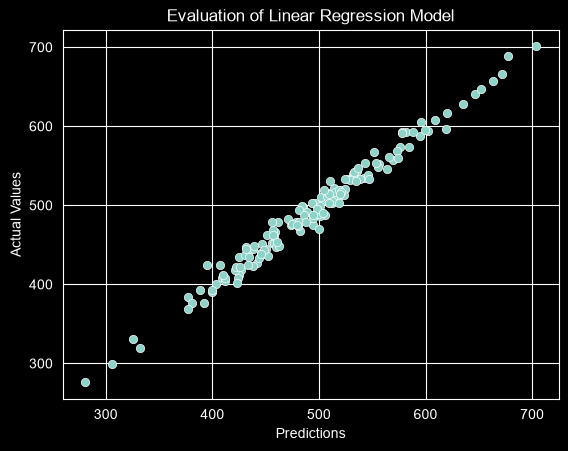

In [44]:
sns.scatterplot(x=y_predict, y=y_test)
plt.xlabel("Predictions")
plt.ylabel("Actual Values")
plt.title("Evaluation of Linear Regression Model")
plt.show()

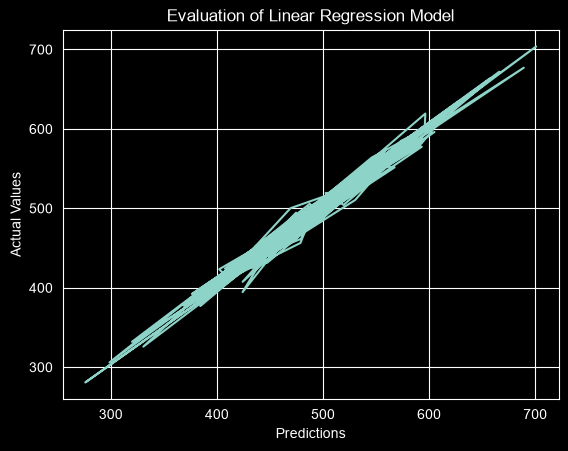

In [45]:
plt.plot(y_test, y_predict)
plt.xlabel("Predictions")
plt.ylabel("Actual Values")
plt.title("Evaluation of Linear Regression Model")
plt.show()

In [46]:

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_predict,
})

results["Error"] = results["Predicted"] - results["Actual"]

print(results)

         Actual   Predicted      Error
361  401.033135  403.669931   2.636795
73   534.777188  542.577563   7.800375
374  418.602742  427.065917   8.463174
155  503.978379  502.024604  -1.953775
104  410.069611  410.121436   0.051825
..          ...         ...        ...
266  554.003093  543.675918 -10.327176
23   519.340989  504.313005 -15.027984
222  502.409785  519.188022  16.778237
261  514.009818  520.031552   6.021734
426  530.766719  535.138550   4.371832

[150 rows x 3 columns]


In [48]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(y_test, y_predict)

print("MAPE:", mape)
print("Percentage Error:", mape * 100, "%")

MAPE: 0.01758380981791404
Percentage Error: 1.758380981791404 %


In [ ]:
## Evaluation done